In [1]:
import os
from jarvis.db.jsonutils import loadjson, dumpjson


In [2]:
path = "./2_results_mbj_bandgap"

previous_mistral_trainer = loadjson(os.path.join(path, "mistral-7b-bnb-4bit_trainer_stats.json"))
previous_mistral_log_history = loadjson(os.path.join(path, "mistral-7b-bnb-4bit_trainer_state_log_history.json"))
previous_mistral_log_history_loss  = [values.get('epoch') for values in previous_mistral_log_history], [values.get('loss') for values in previous_mistral_log_history]

In [3]:
previous_mistral_trainer

[8912,
 0.1680268396889286,
 {'train_runtime': 48523.1476,
  'train_samples_per_second': 2.939,
  'train_steps_per_second': 0.184,
  'total_flos': 2.2272922922419814e+18,
  'train_loss': 0.1680268396889286,
  'epoch': 8.0}]

In [4]:
path = "./results"

new_mistral_trainer = loadjson(os.path.join(path, "mistral-7b-bnb-4bit_trainer_stats.json"))
new_mistral_log_history = loadjson(os.path.join(path, "mistral-7b-bnb-4bit_trainer_state_log_history.json"))
new_mistral_log_history_loss  = [values.get('epoch') for values in new_mistral_log_history], [values.get('loss') for values in new_mistral_log_history]
new_mistral_trainer

[8912,
 0.16758778439358185,
 {'train_runtime': 52476.0969,
  'train_samples_per_second': 2.717,
  'train_steps_per_second': 0.17,
  'total_flos': 2.2395311400784036e+18,
  'train_loss': 0.16758778439358185,
  'epoch': 8.0}]

(0.0, 8.0)

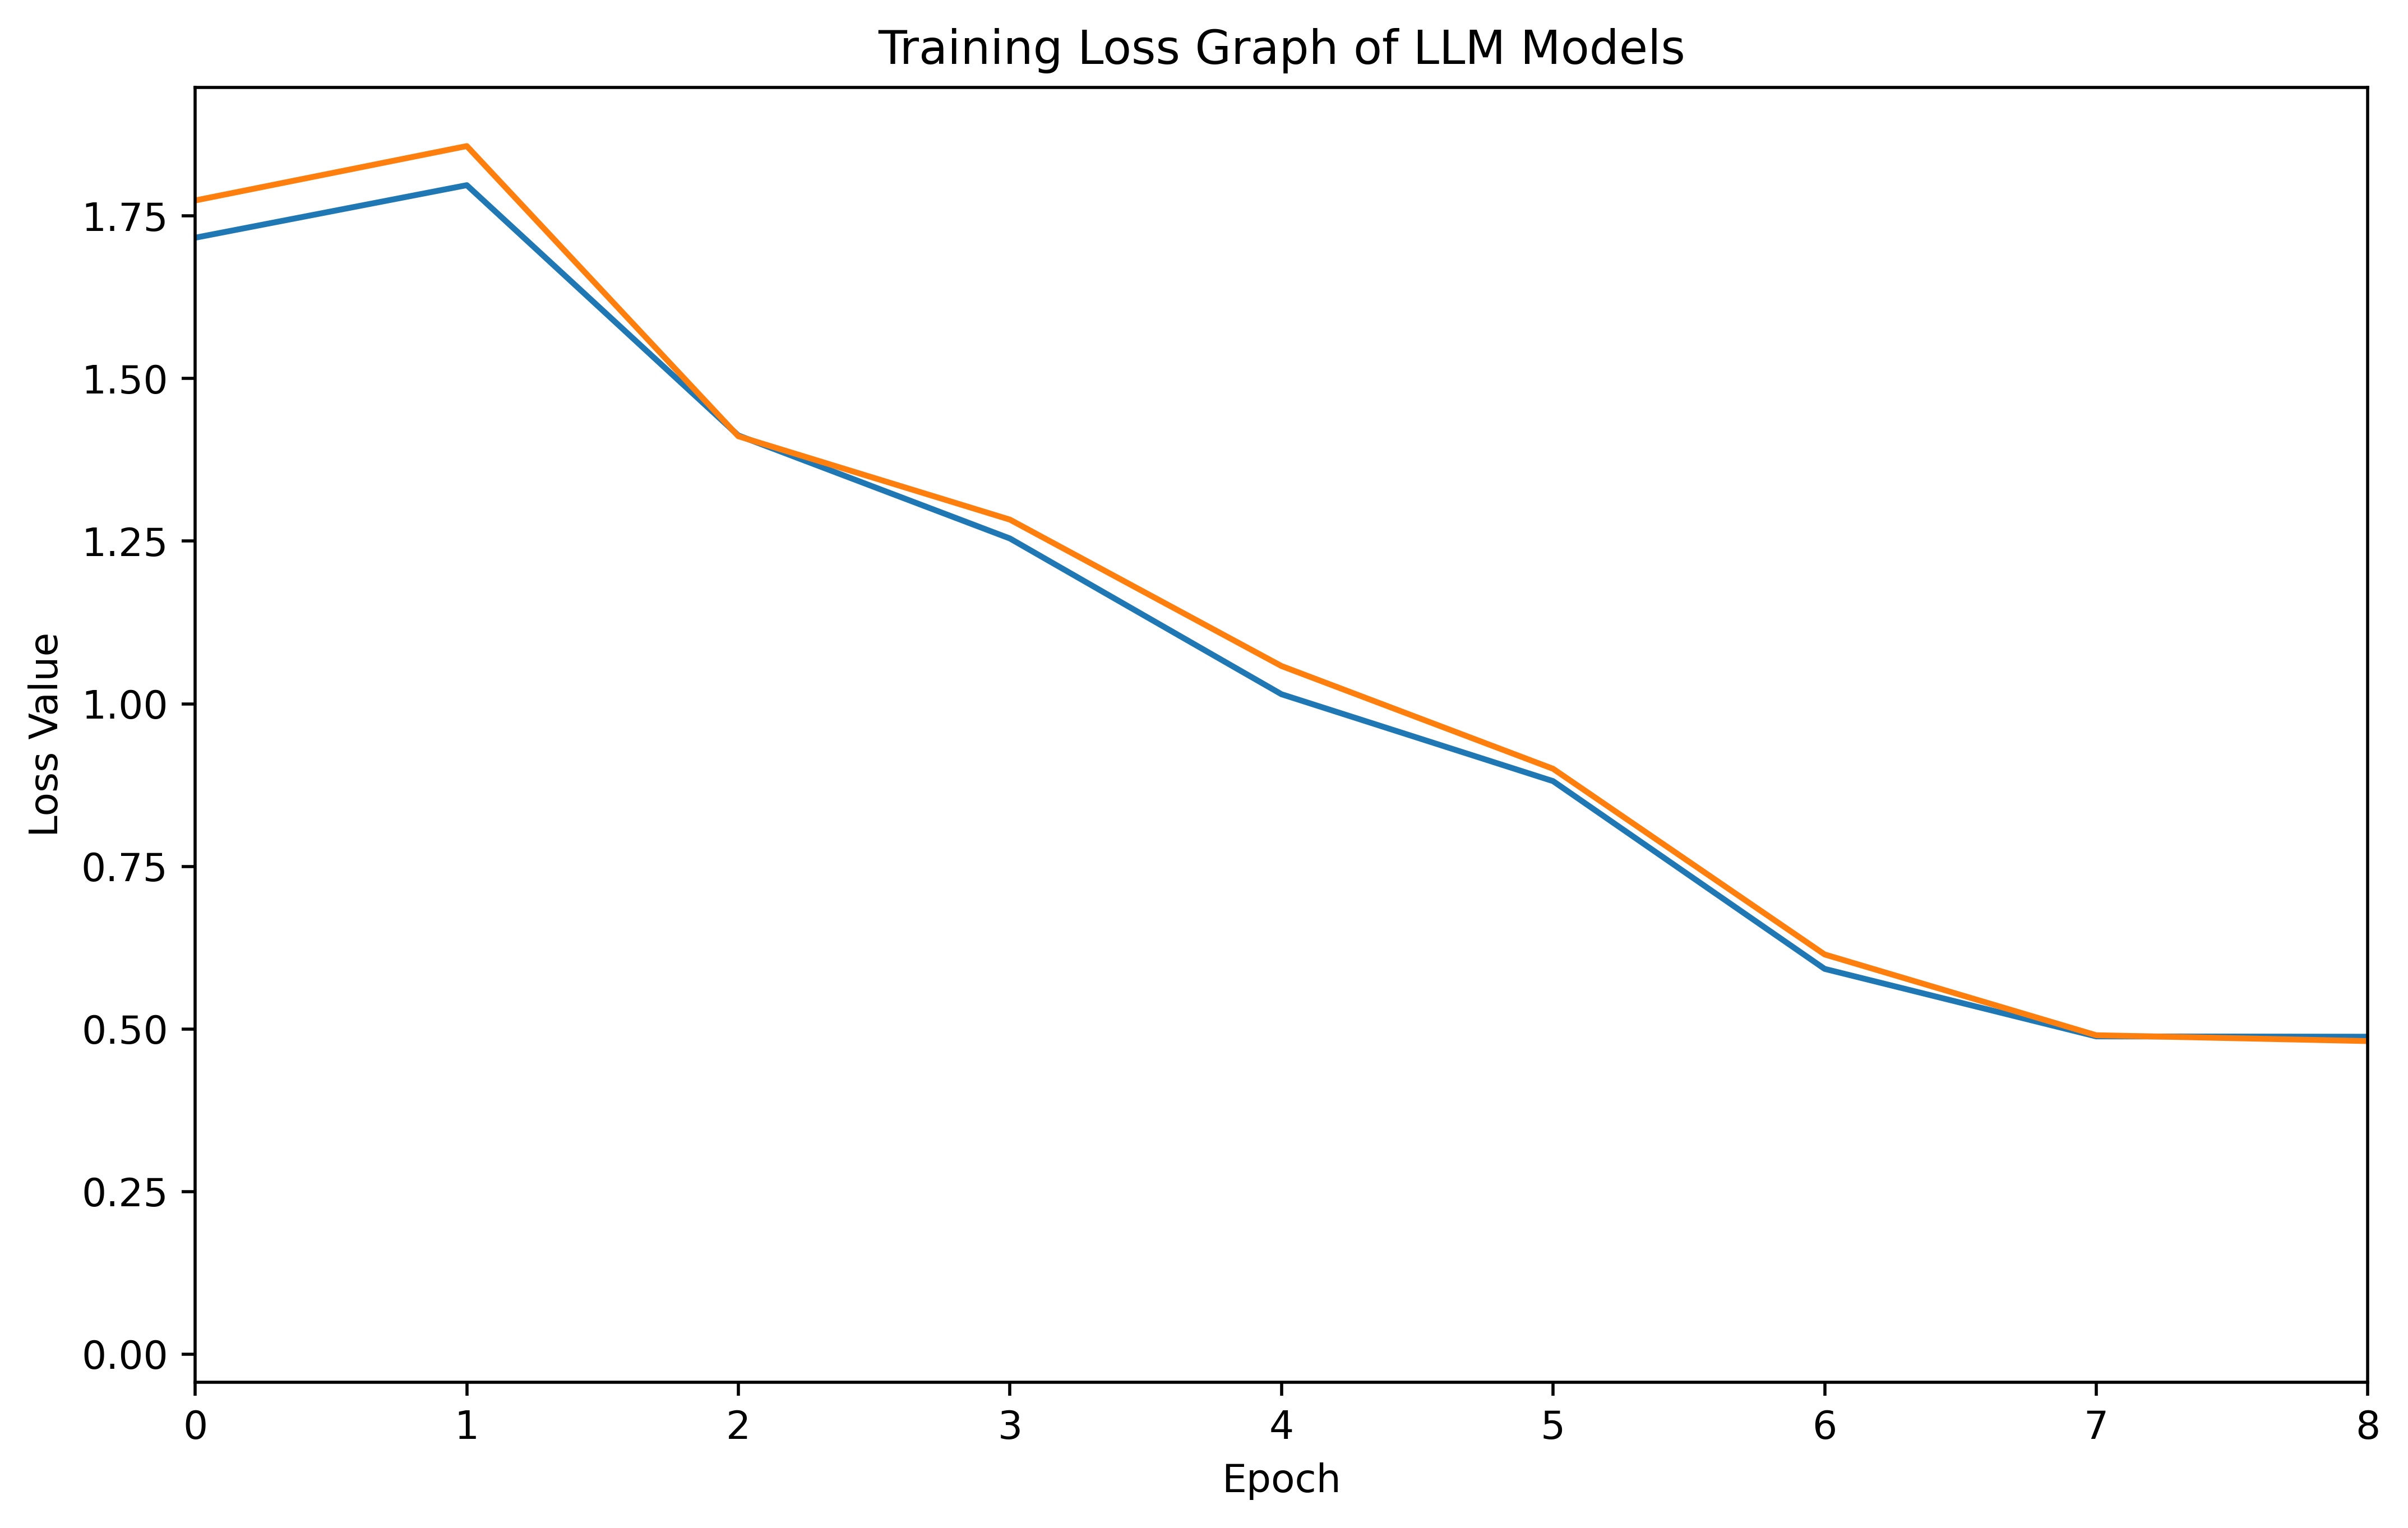

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6),dpi =500)
plt.title('Training Loss Graph of LLM Models')
plt.plot(previous_mistral_log_history_loss[1])#,previous_mistral_log_history_loss[1], label = f"With Superconductor", color = "blue")
plt.plot(new_mistral_log_history_loss[1])#, new_mistral_log_history_loss[1], label = f"Without Superconductor", color = "red")


plt.xlabel("Epoch")
plt.ylabel("Loss Value")
plt.xlim(0, 8)  # Show only the x range from 2 to 8

In [6]:
# Training Loss Graph of LLM Models 

In [ ]:
import torch, os
import unsloth
import random
import numpy as np
import pandas as pd
from pymatgen.core.structure import Structure
from jarvis.core.atoms import Atoms
import jarvis 
from jarvis.db.jsonutils import loadjson, dumpjson
#from alignn import pretrained

# Alternatively, you can directly set the device
#torch.cuda.set_device(0)  # Replace "1" with the index of the GPU you want to use

from pymatgen.analysis.structure_matcher import StructureMatcher
matcher = StructureMatcher(stol=0.5, angle_tol=10, ltol=0.3)

def set_seed():
    os.environ["WANDB_ANONYMOUS"] = "must"
    random_seed = 42
    random.seed(random_seed)
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    torch.cuda.manual_seed_all(random_seed)
    try:
        import torch_xla.core.xla_model as xm
        xm.set_rng_state(random_seed)
    except ImportError:
        pass
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ["PYTHONHASHSEED"] = str(random_seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = str(":4096:8")
    torch.use_deterministic_algorithms(True)

set_seed()

from models import load_model, get_model, get_trainer, save_model
import os
from unsloth import FastLanguageModel
from datasets import load_dataset
import pandas as pd 
from utils import eval_prompts
from sample_funcs import parse_fn
from transformers import TextStreamer

llm_path = "./models"

llm_model, llm_tokenizer = FastLanguageModel.from_pretrained(os.path.join(llm_path, "mistral-7b-bnb-4bit")) 
FastLanguageModel.for_inference(llm_model)  # Enable native 2x faster inference
# data_test = load_dataset("json", data_files="./data/alpaca_"+ "mbj_bandgap" +"_test.json", split="train") # #optb88vdw_bandgap  mbj_bandgap Tc_supercon
# data_test = data_test.add_column("prompt", eval_prompts(data_test))
# df = pd.DataFrame(data_test)
df = pd.read_csv("./results/mistral_generated_samples_without_superconductor_text.csv")
for jdx, nname in df.iterrows():
    if jdx < 1810:
        continue
    try:
        print("jdx", jdx)
        batch = llm_tokenizer(df["prompt"][jdx], return_tensors="pt")
        batch = {k: v.cuda() for k, v in batch.items()}
        generate_ids = llm_model.generate(
            **batch,
            do_sample=False,
            max_new_tokens=4096,
            pad_token_id=llm_tokenizer.eos_token_id,
            use_cache=True)

        gen_strs = llm_tokenizer.batch_decode(
            generate_ids, 
            skip_special_tokens=True, 
            clean_up_tokenization_spaces=True
            )
        try:
            print("try.......")
            material_str = gen_strs[0].replace(df["prompt"][jdx], "")
            cif_str = parse_fn(material_str)
            df.loc[jdx, 'gen_material_str'] = material_str
            df.loc[jdx, 'gen_material_cif'] = cif_str
            df.loc[jdx, 'orj_material_cif'] = parse_fn(df["response"][jdx])
        except Exception as e: 
                print(e)
        print("str_pred.......")
        str_pred = Structure.from_str(df["gen_material_cif"][jdx], fmt="cif")
        str_tar = Structure.from_str(df["orj_material_cif"][jdx], fmt="cif")
        atoms_pred = jarvis.core.atoms.pmg_to_atoms(str_pred)
        #df.loc[jdx, 'str_pred'] = str_pred
        #df.loc[jdx, 'str_tar'] = str_tar
        df.loc[jdx, 'atoms_pred'] = atoms_pred
        atoms_predd = jarvis.core.atoms.pmg_to_atoms(str_pred).pymatgen_converter()
        atoms_tarr = jarvis.core.atoms.pmg_to_atoms(str_tar).pymatgen_converter()
        rms_dist = matcher.get_rms_anonymous(atoms_predd, atoms_tarr) #594
        df.loc[jdx, 'rms_dist'] = rms_dist[0]
        print("rms_dist", rms_dist[0])
        try:
            df.loc[jdx, 'orj_prop_val'] = float(nname["input"].split("value is ")[1][:-1])
        except Exception as e:
            print('orj_prop_val')
            df.loc[jdx, 'orj_prop_val'] = None
        # try:
        #     out_data_pred = pretrained.get_prediction(
        #         model_name="jv_mbj_bandgap_alignn",
        #         atoms=atoms_pred,
        #     )
        #     df.loc[jdx, 'out_data_pred_relaxed'] = out_data_pred[0]
        # except Exception as e:
        #     print('out_data_pred')
        #     df.loc[jdx, 'out_data_pred_relaxed'] = None
    except Exception as e:
        print(e)
    df.to_csv(f"./results/mistral_generated_samples_without_superconductor_text.csv", index=False)  
df.to_csv(f"./results/mistral_generated_samples_without_superconductor_text.csv", index=False)  
print("Saving ....")


In [19]:
from pymatgen.core.structure import Structure
import jarvis 
from jarvis.core.atoms import Atoms
from alignn import pretrained

import pandas as pd
# Load the CSV file into a DataFrame    
df = pd.read_csv("./results/mistral_generated_samples_without_superconductor_text.csv")
for jdx, nname in df.iterrows():
        print("jdx", jdx)

        try:
            str_pred = Structure.from_str(df["gen_material_cif"][jdx], fmt="cif")
            atoms_pred = jarvis.core.atoms.pmg_to_atoms(str_pred)
            out_data_pred = pretrained.get_prediction(
                model_name="jv_mbj_bandgap_alignn",
                atoms=atoms_pred,
            )
            print("out_data_pred", out_data_pred)
            df.loc[jdx, 'out_data_pred_relaxed'] = out_data_pred[0]
        except Exception as e:
            print('out_data_pred')
            df.loc[jdx, 'out_data_pred_relaxed'] = None
df.to_csv(f"./results/mistral_generated_samples_without_superconductor.csv", index=False)  
    


jdx 0
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [0.09829771518707275]
jdx 1
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [1.1104646921157837]
jdx 2
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [0.5181664228439331]
jdx 3
Using chk file jv_mbj_bandgap_alignn/checkpoint_

/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/io/cif.py:1312: UserWarning: Some occupancies ([2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: Issues encountered while parsing CIF: Some occupancies ([2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=pr

out_data_pred [2.5694992542266846]
jdx 76
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [1.6403552293777466]
jdx 77
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [-0.04272511228919029]
jdx 78
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [5.1537933349609375]
jdx 79
Using ch

/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/io/cif.py:1312: UserWarning: Some occupancies ([2.0, 2.0, 2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: Issues encountered while parsing CIF: Some occupancies ([2.0, 2.0, 2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_str

out_data_pred [3.1577930450439453]
jdx 188
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [5.25537109375]
jdx 189
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [1.990854024887085]
jdx 190
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [-0.007965710014104843]
jdx 191
Using chk

...

out_data_pred [0.07222822308540344]
jdx 1859
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [1.1267516613006592]
jdx 1860
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [-0.006561513990163803]
jdx 1861
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [0.00947645679116249]
jdx 18

/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/io/cif.py:1312: UserWarning: Some occupancies ([2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: Issues encountered while parsing CIF: Some occupancies ([2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=pr

out_data_pred [3.137399911880493]
jdx 1894
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [-0.04274086281657219]
jdx 1895
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [7.0698089599609375]
jdx 1896
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [0.008435163646936417]
jdx 1897

/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/io/cif.py:1312: UserWarning: Some occupancies ([2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
  if struct := self._get_structure(data, primitive, symmetrized, check_occu=check_occu):
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=primitive)[0]
/home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/pymatgen/core/structure.py:3100: UserWarning: Issues encountered while parsing CIF: Some occupancies ([2.0]) sum to > 1! If they are within the occupancy_tolerance, they will be rescaled. The current occupancy_tolerance is set to: 1.0
No structure parsed for section 1 in CIF.
Occupancy 2.0 exceeded tolerance.
  struct = parser.parse_structures(primitive=pr

out_data_pred [0.008708987385034561]
jdx 1925
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [4.24471378326416]
jdx 1926
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [1.2752749919891357]
jdx 1927
Using chk file jv_mbj_bandgap_alignn/checkpoint_300.pt from  ['jv_mbj_bandgap_alignn/checkpoint_300.pt']
Path /home/jipengsun/.conda/envs/llm/lib/python3.10/site-packages/alignn/jv_mbj_bandgap_alignn.zip
Config /home/jipengsun/LLM_Atom_Gen/jv_mbj_bandgap_alignn/config.json
out_data_pred [-0.03500935062766075]
jdx 1928


In [17]:
import dgl
print("DGL version:", dgl.__version__)

DGL version: 2.4.0+cu121


In [22]:
df

,instruction,input,response,prompt,gen_material_str,gen_material_cif,orj_material_cif,atoms_pred,rms_dist,orj_prop_val,out_data_pred_relaxed
0,Generate atomic structure description with lat...,The chemical formula is LiGeS. The mbj_bandga...,5.7 6.6 3.5\n90 90 148\nLi\n-0.11 0.17 0.00\nG...,Below is a description of a material. Write a ...,2.7 2.7 7.7\n90 90 90\nLi\n0.00 0.00 -0.02\nGe...,# generated using pymatgen\ndata_LiGeS\n_symme...,# generated using pymatgen\ndata_LiGeS\n_symme...,System\n1.0\n2.7 0.0 1.6532731788489269e-16\n4...,NaN,0.000,0.098298
1,Generate atomic structure description with lat...,The chemical formula is PrTeCl. The mbj_bandg...,4.5 4.5 8.3\n90 90 90\nPr\n0.50 0.00 0.76\nPr\...,Below is a description of a material. Write a ...,4.5 4.5 8.2\n90 90 90\nPr\n0.50 0.00 0.76\nPr\...,# generated using pymatgen\ndata_PrTeCl\n_symm...,# generated using pymatgen\ndata_PrTeCl\n_symm...,System\n1.0\n4.5 0.0 2.755455298081545e-16\n7....,0.000000e+00,0.880,1.110465
2,Generate atomic structure description with lat...,The chemical formula is FeSb4O12. The mbj_ban...,5.0 5.5 7.5\n83 89 91\nFe\n-0.00 0.39 0.71\nSb...,Below is a description of a material. Write a ...,6.7 6.7 5.4\n74 105 96\nFe\n0.50 0.50 0.50\nSb...,# generated using pymatgen\ndata_Fe(SbO3)4\n_s...,# generated using pymatgen\ndata_Fe(SbO3)4\n_s...,System\n1.0\n6.471703036136758 0.0 -1.73408760...,NaN,0.000,0.518166
3,Generate atomic structure description with lat...,The chemical formula is VS2. The mbj_bandgap ...,5.3 5.3 6.2\n115 115 90\nV\n0.25 0.75 0.50\nV\...,Below is a description of a material. Write a ...,3.2 3.2 5.8\n90 90 119\nV\n0.00 0.00 0.00\nS\n...,# generated using pymatgen\ndata_VS2\n_symmetr...,# generated using pymatgen\ndata_VS2\n_symmetr...,System\n1.0\n3.2 0.0 1.9594348786357652e-16\n-...,NaN,0.000,-0.006322
4,Generate atomic structure description with lat...,The chemical formula is FeIr3. The mbj_bandga...,3.8 3.8 3.8\n90 90 90\nFe\n0.00 0.00 0.00\nIr\...,Below is a description of a material. Write a ...,3.8 3.8 3.8\n90 90 90\nFe\n0.00 0.00 0.00\nIr\...,# generated using pymatgen\ndata_FeIr3\n_symme...,# generated using pymatgen\ndata_FeIr3\n_symme...,System\n1.0\n3.8 0.0 2.326828918379971e-16\n6....,0.000000e+00,0.000,-0.028908
...,...,...,...,...,...,...,...,...,...,...,...
1976,Generate atomic structure description with lat...,The chemical formula is Ba4TiNi. The mbj_band...,7.0 7.0 7.0\n60 60 60\nBa\n0.13 0.62 0.62\nBa\...,Below is a description of a material. Write a ...,6.9 6.9 6.9\n60 60 60\nBa\n0.13 0.62 0.62\nBa\...,# generated using pymatgen\ndata_Ba4TiNi\n_sym...,# generated using pymatgen\ndata_Ba4TiNi\n_sym...,System\n1.0\n5.975575286112627 0.0 3.450000000...,3.455104e-16,0.000,-0.015942
1977,Generate atomic structure description with lat...,The chemical formula is CdPd2Au. The mbj_band...,4.6 4.6 4.6\n60 60 60\nCd\n0.00 0.00 0.00\nPd\...,Below is a description of a material. Write a ...,4.6 4.6 4.6\n60 60 60\nCd\n0.00 0.00 0.00\nPd\...,# generated using pymatgen\ndata_CdPd2Au\n_sym...,# generated using pymatgen\ndata_CdPd2Au\n_sym...,System\n1.0\n3.9837168574084174 0.0 2.30000000...,2.719824e-16,0.000,-0.011000
1978,Generate atomic structure description with lat...,The chemical formula is LiSm2Ru. The mbj_band...,5.0 5.0 5.0\n60 60 60\nLi\n0.25 0.25 0.25\nSm\...,Below is a description of a material. Write a ...,4.9 4.9 4.9\n60 60 60\nLi\n0.25 0.25 0.25\nSm\...,# generated using pymatgen\ndata_LiSm2Ru\n_sym...,# generated using pymatgen\ndata_LiSm2Ru\n_sym...,System\n1.0\n4.243524478543749 0.0 2.450000000...,4.051132e-16,0.000,-0.007544
1979,Generate atomic structure description with lat...,The chemical formula is Li2V3O6. The mbj_band...,5.1 5.0 5.0\n60 71 80\nLi\n-0.00 0.34 0.33\nLi...,Below is a description of a material. Write a ...,4.9 4.9 4.9\n90 119 119\nLi\n0.50 0.00 0.50\nL...,# generated using pymatgen\ndata_Li2V3O6\n_sym...,# generated using pymatgen\ndata_Li2V3O6\n_sym...,System\n1.0\n4.28563656498304 0.0 -2.3

In [23]:
# Table 3 
num_samples = df.shape[0]
print("Number of Samples", num_samples)

nans = df['rms_dist'].isna().sum()

print("*Number of NANs in rms_dist", nans)

print("*NANs ratio rms_dist", nans/num_samples)

print("*Mean Rms_dist", df['rms_dist'].sum()/(num_samples-nans))

df["result"] = abs(df['out_data_pred_relaxed'] - df['orj_prop_val'])

nan_alignn = df['result'].isna().sum()

print("***NANs Ratio in Result", (nan_alignn/num_samples))

print("***Mean Eror Ratio", df["result"].sum()/(num_samples - nan_alignn))

print("***********")

Number of Samples 1981
*Number of NANs in rms_dist 1045
*NANs ratio rms_dist 0.5275113579000504
*Mean Rms_dist 0.049243339677716776
***NANs Ratio in Result 0.013629480060575468
***Mean Eror Ratio 0.5342471752467974
***********


In [24]:
import numpy as np
def loss_calc(org_str, gen_str):
    
    try:

        x_lines = [x for x in org_str.split("\n") if len(x) > 0]
        x_lengths = [float(x) for x in x_lines[0].split(" ")]
        x_angles = [float(x) for x in x_lines[1].split(" ")]
        x_species = [x for x in x_lines[2::2]]
        x_coords = [[float(y) for y in x.split(" ")] for x in x_lines[3::2]]

        y_lines = [x for x in gen_str.split("\n") if len(x) > 0]
        y_lengths = [float(x) for x in y_lines[0].split(" ")]
        y_angles = [float(x) for x in y_lines[1].split(" ")]
        y_species = [x for x in y_lines[2::2]]
        y_coords = [[float(y) for y in x.split(" ")] for x in y_lines[3::2]]
    except Exception as e:
        #print(e)
        return 0, 0, 0, 0

    # Mean Absolute Error (MAE)
    try:
        lenght_loss = np.mean(np.abs((np.array(x_lengths) - np.array(y_lengths))))
        angle_loss = np.mean(np.abs((np.array(x_angles) - np.array(y_angles))))
        coord_loss = np.mean(np.abs((np.array(x_coords) - np.array(y_coords))))
        return lenght_loss, angle_loss, coord_loss, 1
    except Exception as e:
        #print(e)
        return 0, 0, 0, 0
    

def get_lenght(org_str, gen_str):

    try:
        x_lines = [x for x in org_str.split("\n") if len(x) > 0]
        x_lengths = [float(x) for x in x_lines[0].split(" ")]

        y_lines = [x for x in gen_str.split("\n") if len(x) > 0]
        y_lengths = [float(x) for x in y_lines[0].split(" ")]
        
        return x_lengths, y_lengths, 1


    except Exception as e:
        return 0, 0, 0




angle_loss_ = []
lenght_loss_ = []
coord_loss_ = []

for jdx, nname in df.iterrows():

    xx = df.iloc[jdx]["response"]
    yy = df.iloc[jdx]["gen_material_str"]

    lenght_loss, angle_loss, coord_loss, correct = loss_calc(xx, yy)
    if correct:
        angle_loss_.append(angle_loss)
        lenght_loss_.append(lenght_loss)
        coord_loss_.append(coord_loss)

print("len", len(df), "calculated", len(coord_loss_),  "coord_loss_", np.mean(coord_loss_), "lenght_loss_", np.mean(lenght_loss_), "angle_loss_", np.mean(angle_loss_))

len 1981 calculated 1490 coord_loss_ 0.21303851962642603 lenght_loss_ 0.5872035794183446 angle_loss_ 10.518568232662194
